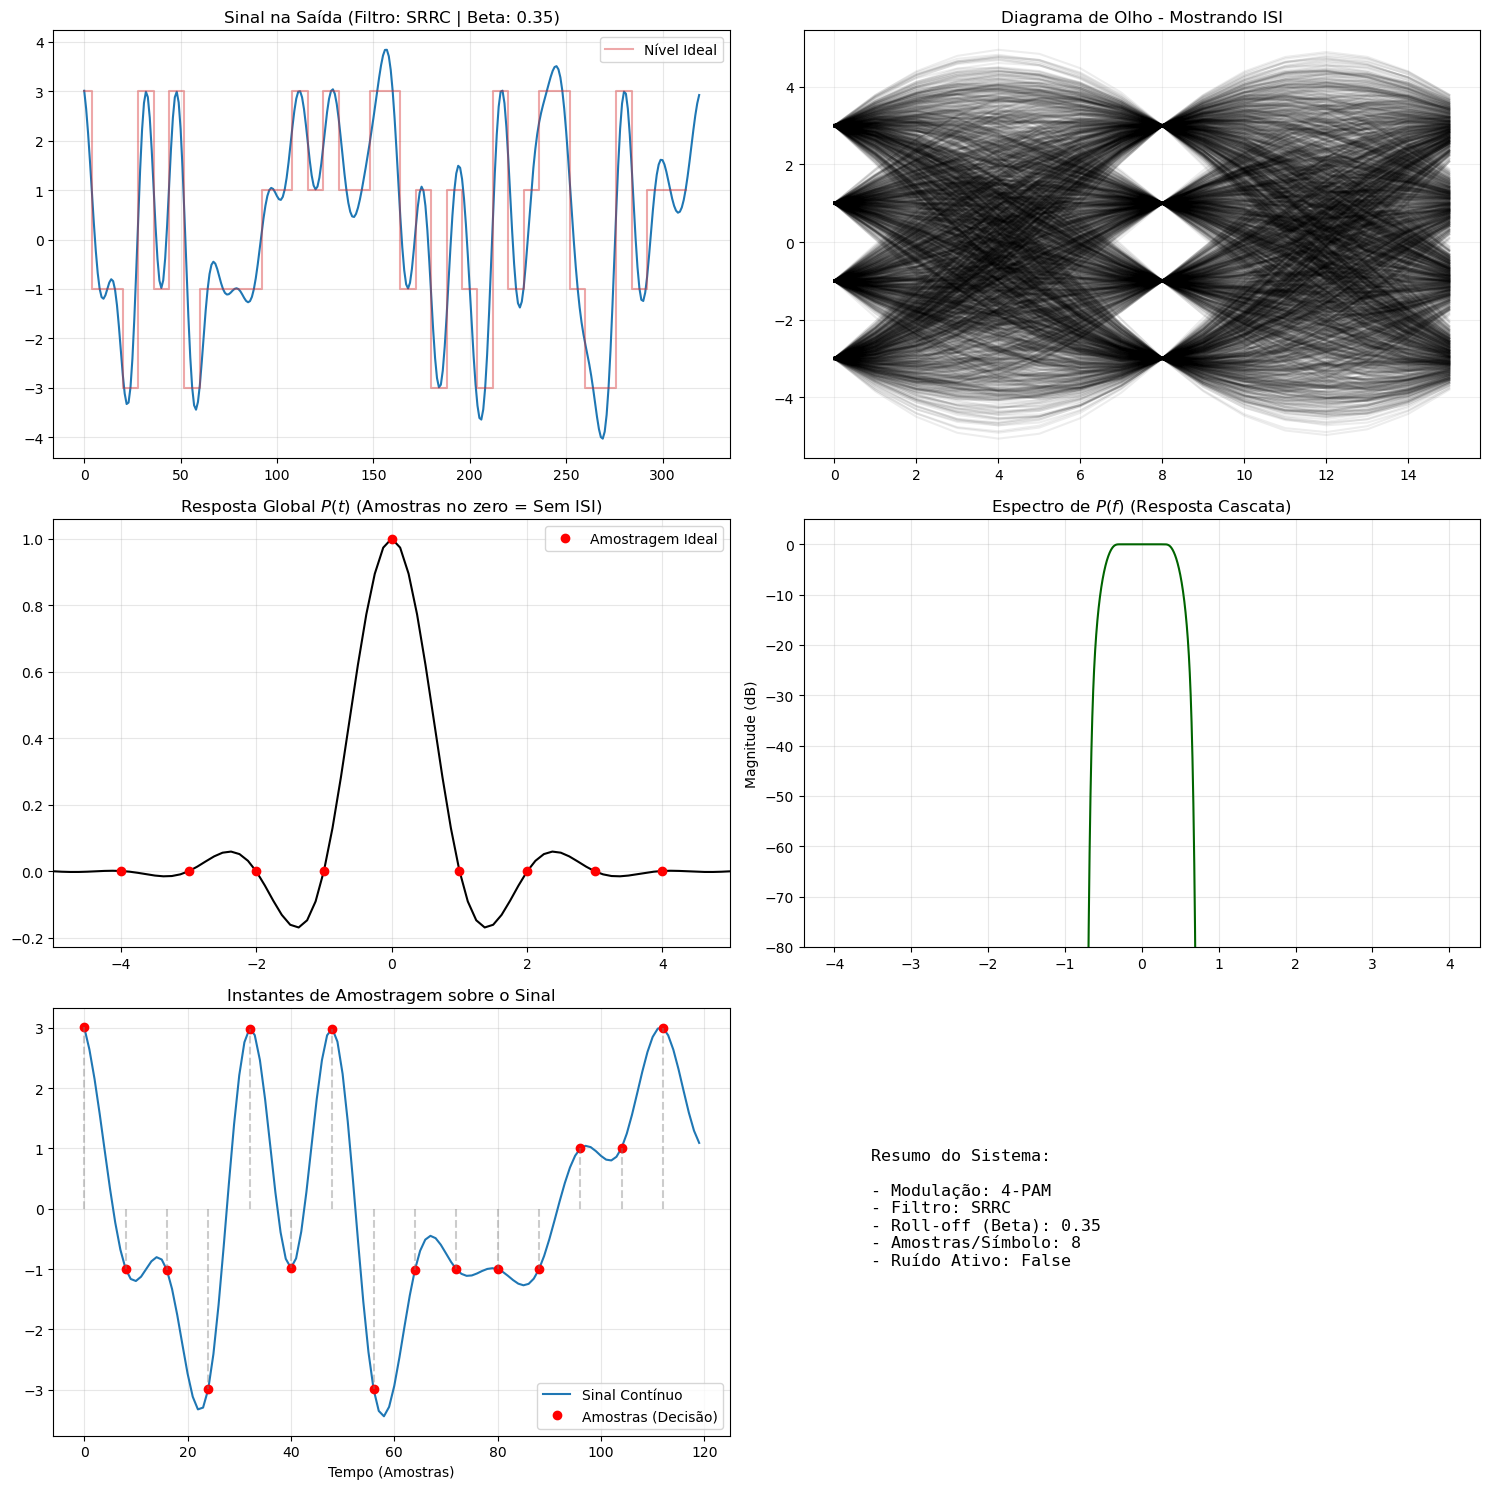

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURAÇÕES DO SISTEMA ---
M = 4               # Ordem PAM (2, 4, 8, 16)
sps = 8             # Amostras por símbolo (Samples per symbol)
num_symbols = 5000  # Quantidade de símbolos
rolloff = 0.35      # Fator de decaimento (Tente valores próximos de zero!)
noise_on = False    # Ligar/Desligar ruído
noise_var = 0.05    # Variância do ruído (Potência)
# OPÇÕES DE FILTRO: 'SRRC', 'RECT', 'GAUSS', 'EXP', 'TRI'
filter_type = 'SRRC' 

# --- 1. GERAÇÃO DE SÍMBOLOS E UPSAMPLING ---
symbols = np.random.choice(np.arange(-(M-1), M, 2), num_symbols)
upsampled = np.zeros(num_symbols * sps)
upsampled[::sps] = symbols

# --- 2. DEFINIÇÃO EXPANDIDA DOS FILTROS (Com correção para Roll-off baixo) ---
def get_filter(ftype, sps, beta):
    # Aumentamos o span para 32 símbolos para evitar ISI por truncamento em betas baixos
    span = 32 
    t = np.arange(-span/2 * sps, span/2 * sps + 1) / sps
    
    if ftype == 'SRRC':
        h = np.zeros(len(t))
        b = max(beta, 1e-9) # Evita divisão por zero
        for i, ti in enumerate(t):
            if ti == 0: 
                h[i] = 1 - b + 4*b/np.pi
            elif abs(ti) == 1/(4*b):
                h[i] = (b/np.sqrt(2)) * ((1+2/np.pi)*np.sin(np.pi/(4*b)) + (1-2/np.pi)*np.cos(np.pi/(4*b)))
            else:
                num = np.sin(np.pi*ti*(1-b)) + 4*b*ti*np.cos(np.pi*ti*(1+b))
                den = np.pi*ti*(1-(4*b*ti)**2)
                h[i] = num / den
        
        # Aplicação de Janela de Hamming para mitigar o Fenômeno de Gibbs (ISI de truncamento)
        h *= np.hamming(len(t))
        
    elif ftype == 'RECT':
        h = np.ones(sps)
    elif ftype == 'GAUSS':
        # Filtro Gaussiano (BT=0.3 tipicamente gera muita ISI)
        h = np.exp(-np.pi * (t / 0.5)**2)
    elif ftype == 'EXP':
        # Filtro Exponencial (Assimétrico - Viola simetria vestigial)
        h = np.exp(-t) * (t >= 0)
    elif ftype == 'TRI':
        # Filtro Triangular
        h = np.maximum(0, 1 - np.abs(t/1.5))
    
    return h / np.sqrt(np.sum(h**2))

tx_filter = get_filter(filter_type, sps, rolloff)
rx_filter = tx_filter 

# --- 3. PROCESSAMENTO ---
tx_signal = np.convolve(upsampled, tx_filter, mode='same')
rx_input = tx_signal + (np.random.normal(0, np.sqrt(noise_var), len(tx_signal)) if noise_on else 0)
rx_output = np.convolve(rx_input, rx_filter, mode='same')

# Resposta Global P(t) - Cascata TX e RX
p_t = np.convolve(tx_filter, rx_filter, mode='full')
t_p = (np.arange(len(p_t)) - len(p_t)//2) / sps

# --- 4. VISUALIZAÇÃO ---
fig, axs = plt.subplots(3, 2, figsize=(15, 15)) # Layout 3x2 para incluir o novo gráfico

# A. FORMA DE ONDA
axs[0, 0].plot(rx_output[len(rx_output)//2 : len(rx_output)//2 + sps*40], color='tab:blue')
axs[0, 0].step(np.arange(0, sps*40, sps), symbols[num_symbols//2:num_symbols//2+40], where='mid', color='tab:red', alpha=0.4, label='Nível Ideal')
axs[0, 0].set_title(f'Sinal na Saída (Filtro: {filter_type} | Beta: {rolloff})')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

# B. DIAGRAMA DE OLHO (COR PRETA)
# Aumentamos o offset inicial para ignorar o transiente do filtro longo
start, end = 100 * sps, len(rx_output) - 100 * sps
for i in range(start, end - 2*sps, 2*sps):
    axs[0, 1].plot(rx_output[i : i + 2*sps], color='black', alpha=0.07) # Alpha reduzido para densidade de 5000 símbolos
axs[0, 1].set_title(f'Diagrama de Olho - Mostrando ISI')
axs[0, 1].grid(True, alpha=0.2)

# C. RESPOSTA AO IMPULSO P(t)
axs[1, 0].plot(t_p, p_t / np.max(p_t), color='black', lw=1.5)
samples = np.arange(-4, 5, 1)
axs[1, 0].plot(samples, [1 if x==0 else 0 for x in samples], 'ro', label='Amostragem Ideal')
axs[1, 0].set_title('Resposta Global $P(t)$ (Amostras no zero = Sem ISI)')
axs[1, 0].set_xlim([-5, 5])
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

# D. RESPOSTA EM FREQUÊNCIA P(f)
N_fft = 4096
P_f = np.fft.fftshift(np.fft.fft(p_t, N_fft))
freqs = np.linspace(-sps/2, sps/2, N_fft)
axs[1, 1].plot(freqs, 20 * np.log10(np.abs(P_f) / np.max(np.abs(P_f))), color='darkgreen')
axs[1, 1].set_title('Espectro de $P(f)$ (Resposta Cascata)')
axs[1, 1].set_ylabel('Magnitude (dB)')
axs[1, 1].set_ylim([-80, 5])
axs[1, 1].grid(True, alpha=0.3)

# E. NOVO: FORMA DE ONDA COM INSTANTES DE AMOSTRAGEM (ZOOM)
# Visualização focada nos instantes de decisão (amostragem ideal)
num_view = 15 # Mostrar 15 símbolos
start_idx = len(rx_output)//2
time_range = np.arange(0, num_view * sps)
signal_segment = rx_output[start_idx : start_idx + num_view * sps]
sample_idx = np.arange(0, num_view * sps, sps)
sample_vals = signal_segment[sample_idx]

axs[2, 0].plot(time_range, signal_segment, color='tab:blue', label='Sinal Contínuo')
axs[2, 0].plot(sample_idx, sample_vals, 'ro', label='Amostras (Decisão)')
axs[2, 0].vlines(sample_idx, 0, sample_vals, colors='gray', linestyles='--', alpha=0.4)
axs[2, 0].set_title('Instantes de Amostragem sobre o Sinal')
axs[2, 0].set_xlabel('Tempo (Amostras)')
axs[2, 0].grid(True, alpha=0.3)
axs[2, 0].legend()

# F. RESUMO DAS CONFIGURAÇÕES (Mantendo o espaço extra organizado)
axs[2, 1].axis('off')
axs[2, 1].text(0.1, 0.4, f"Resumo do Sistema:\n\n- Modulação: {M}-PAM\n- Filtro: {filter_type}\n- Roll-off (Beta): {rolloff}\n- Amostras/Símbolo: {sps}\n- Ruído Ativo: {noise_on}", fontsize=12, family='monospace')

plt.tight_layout()
plt.show()